##### Ideal QSVM (SVC Precomputed Kernel) - Spambase

In [1]:
import qiskit, qiskit_aer, qiskit_machine_learning
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("QML:", qiskit_machine_learning.__version__)

Qiskit: 1.4.4
Aer: 0.17.2
QML: 0.8.4


In [3]:
# To ensure reproducibility of results
from qiskit_machine_learning.utils import algorithm_globals
algorithm_globals.random_seed = 12345

In [2]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, recall_score, balanced_accuracy_score

In [4]:
# --- Qiskit Imports ---
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC, PegasosQSVC

Load Dataset

In [5]:
# --- Import Spambase Column Names ---
spambase_columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    "label"
]

# --- 1. Load the Spambase Dataset (LOCAL PATH) ---
# file_path = '/kaggle/input/spambase/spambase.data'
file_path = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\spambase\spambase.data'
df = pd.read_csv(file_path, header=None, names=spambase_columns)
df.drop_duplicates(inplace=True)

print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")

Dataset loaded: 4210 samples, 58 features


Experiment Configurations

In [6]:
# ==========================================
# EXPERIMENT CONFIGURATIONS
# ==========================================

experiments = [
    # --- EXP 1: Sample Size Effect (Generalization) ---
    {'id': 'Exp1_500samp',  'samples': 500, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_1000samp',  'samples': 1000, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_1500samp',  'samples': 1500, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},

    # --- EXP 2: Dimensionality Effect (Quantum Complexity) ---
    {'id': 'Exp2_4feat',   'samples': 300, 'k_features': 2,  'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_8feat',   'samples': 300, 'k_features': 4,  'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_10feat',  'samples': 300, 'k_features': 6, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_10feat',  'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_10feat',  'samples': 300, 'k_features': 10, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_10feat',  'samples': 300, 'k_features': 12, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},

    # --- EXP 3: Shot Noise Effect (Measurement Precision) ---
    {'id': 'Exp3_128shots',  'samples': 300, 'k_features': 8, 'shots': 128,  'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp3_512shots',  'samples': 300, 'k_features': 8, 'shots': 512,  'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp3_1024shots', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},

    # --- EXP 4: Reps Effect (NEW: Circuit Complexity) ---
    {'id': 'Exp4_Reps1', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1,  'entanglement': 'linear'},  
    {'id': 'Exp4_Reps2', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 2,  'entanglement': 'linear'},  
    {'id': 'Exp4_Reps3', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 3,  'entanglement': 'linear'},

    # --- EXP 5: Entanglement Ablation (NEW) ---1
    {'id': 'Exp5_Linear',  'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp5_Circular', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'circular'},
    {'id': 'Exp5_Full',    'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'full'},
]

print(f"Total experiments configured: {len(experiments)}")
print("Running might take hours or even several days")


Total experiments configured: 18
Running might take hours or even several days


Main Experiment

In [7]:
# ==========================================
# MAIN EXPERIMENT LOOP
# ==========================================

# Store all results
all_results = []

# Split features and target once
X = df.drop('label', axis=1)
y = df['label']

for exp_num, config in enumerate(experiments, 1):
    print("\n" + "=" * 80)
    print(f"EXPERIMENT {exp_num}/{len(experiments)}: {config['id']}")
    print("=" * 80)
    print(f"  Samples: {config['samples']}")
    print(f"  K Features: {config['k_features']}")
    print(f"  Shots: {config['shots']}")
    print(f"  Reps: {config['reps']}")
    print(f"  Entanglement: {config['entanglement']}")
    print("=" * 80)

    # ===================================================================
    # 1. CREATE DATASET BASED ON SAMPLE SIZE
    # ===================================================================

    train_samples = config['samples']
    subset_size = int(round(train_samples / 0.7))

    # First sample subset from full dataset
    X_subset, _, y_subset, _ = train_test_split(
        X, y,
        train_size=subset_size,
        stratify=y,
        random_state=42
    )

    # Then do 70:30 split
    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y_subset,
        test_size=0.30,
        random_state=42,
        stratify=y_subset
    )

    print(f"\nDataset created: {X_train.shape[0]} train, {X_test.shape[0]} test")

    # ===================================================================
    # 2. SCALING
    # ===================================================================

    # 2. VARIANCE FILTERING & SCALING (Prevents "Invalid Value" errors)
    selector_variance = VarianceThreshold(threshold=0)
    X_train_filtered = selector_variance.fit_transform(X_train)
    X_test_filtered = selector_variance.transform(X_test)
    remaining_cols = X_train.columns[selector_variance.get_support()]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_filtered)
    X_test_scaled = scaler.transform(X_test_filtered)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=remaining_cols)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=remaining_cols)

    print("Data scaled successfully")

    # ===================================================================
    # 3. CORRELATION-BASED FEATURE DROPPING
    # ===================================================================

    THRESH = 0.9
    corr_matrix_train = X_train_scaled_df.corr().abs()
    upper_triangle = corr_matrix_train.where(
        np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
    )

    columns_to_drop = set()
    for column in upper_triangle.columns:
        high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
        if high_corr_partners:
            for partner in high_corr_partners:
                corr_main_vs_target = y_train.corr(X_train_scaled_df[column])
                corr_partner_vs_target = y_train.corr(X_train_scaled_df[partner])

                if abs(corr_main_vs_target) < abs(corr_partner_vs_target):
                    columns_to_drop.add(column)
                else:
                    columns_to_drop.add(partner)

    to_drop_final = sorted(list(columns_to_drop))
    X_train_selected = X_train_scaled_df.drop(columns=to_drop_final)
    X_test_selected = X_test_scaled_df.drop(columns=to_drop_final)

    print(f"Dropped {len(to_drop_final)} highly correlated features")

    # ===================================================================
    # 4. SELECTKBEST
    # ===================================================================

    k_features = config['k_features']
    selector = SelectKBest(score_func=f_classif, k=k_features)
    X_train_kbest = selector.fit_transform(X_train_selected, y_train)
    X_test_kbest = selector.transform(X_test_selected)
    

    selected_features = X_train_selected.columns[selector.get_support()].tolist()
    print(f"SelectKBest: Selected {k_features} features:")
    for i, feat in enumerate(selected_features, 1):
      print(f"     {i}. {feat}")

    # ===================================================================
    # 5. QUANTUM KERNEL SETUP (GPU-ENABLED)
    # ===================================================================

    fm = ZZFeatureMap(
        feature_dimension=k_features,
        reps=config['reps'],
        entanglement=config['entanglement']
    )

    sampler = Sampler(default_shots=config['shots'])
    fidelity = ComputeUncompute(sampler=sampler)
    qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fm)

    print(f"Quantum kernel configured (ZZFeatureMap, reps={config['reps']}, entanglement={config['entanglement']})")

    # ===================================================================
    # 6. COMPUTE KERNEL MATRICES
    # ===================================================================

    print("\nComputing kernel matrices...")
    start_kernel = time.time()

    matrix_train = qkernel.evaluate(x_vec=X_train_kbest)
    matrix_test = qkernel.evaluate(x_vec=X_test_kbest, y_vec=X_train_kbest)

    kernel_time = time.time() - start_kernel
    print(f"Kernel computation: {kernel_time:.2f}s")

    # ===================================================================
    # 7. GRID SEARCH
    # ===================================================================

    print("\nGrid searching for optimal C...")
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'),
        param_grid,
        cv=cv,
        scoring='accuracy',
        verbose=0,
        n_jobs=-1
    )

    start_train = time.time()
    grid_search.fit(matrix_train, y_train)
    train_time = time.time() - start_train

    best_model = grid_search.best_estimator_
    best_c = grid_search.best_params_['C']
    cv_score = grid_search.best_score_

    print(f"  → Best C: {best_c}")
    print(f"  → CV Score: {cv_score:.4f}")
    print(f"  → Training time: {train_time:.2f}s")

    # ===================================================================
    # 8. EVALUATION
    # ===================================================================

    y_train_pred = best_model.predict(matrix_train)
    y_test_pred = best_model.predict(matrix_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    spam_recall = recall_score(y_test, y_test_pred, pos_label=1)
    gen_gap = abs(train_acc - test_acc)

    print(f"  → Train Accuracy: {train_acc:.4f}")
    print(f"  → Test Accuracy: {test_acc:.4f}")
    print(f"  → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"  → Spam Recall: {spam_recall:.4f}")
    print(f"  → Generalization Gap: {gen_gap:.4f}")

    # ===================================================================
    # 9. STORE RESULTS
    # ===================================================================

    all_results.append({
        'experiment_id': config['id'],
        'exp_number': exp_num,
        'samples': config['samples'],
        'k_features': k_features,
        'shots': config['shots'],
        'reps': config['reps'],
        'entanglement': config['entanglement'],
        'selected_features': selected_features,
        'best_c': best_c,
        'cv_score': cv_score,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test_balanced_acc': test_balanced_acc,
        'spam_recall': spam_recall,
        'gen_gap': gen_gap,
        'kernel_time': kernel_time,
        'train_time': train_time
    })

    # Print classification report
    print("\n" + "Classification Report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Save kernel matrices
    np.save(f'kernel_train_{config["id"]}.npy', matrix_train)
    np.save(f'kernel_test_{config["id"]}.npy', matrix_test)
    print(f"Saved kernel matrices: kernel_train_{config['id']}.npy, kernel_test_{config['id']}.npy")

print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETE!")
print("=" * 80)



EXPERIMENT 1/18: Exp1_500samp
  Samples: 500
  K Features: 8
  Shots: 1024
  Reps: 1
  Entanglement: linear

Dataset created: 499 train, 215 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:
     1. word_freq_remove
     2. word_freq_free
     3. word_freq_business
     4. word_freq_your
     5. word_freq_000
     6. word_freq_money
     7. char_freq_!
     8. char_freq_$
Quantum kernel configured (ZZFeatureMap, reps=1, entanglement=linear)

Computing kernel matrices...


c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Kernel computation: 1635.35s

Grid searching for optimal C...
  → Best C: 10
  → CV Score: 0.8678
  → Training time: 4.81s
  → Train Accuracy: 0.9820
  → Test Accuracy: 0.8372
  → Test Balanced Accuracy: 0.8450
  → Spam Recall: 0.8837
  → Generalization Gap: 0.1448

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       129
           1       0.75      0.88      0.81        86

    accuracy                           0.84       215
   macro avg       0.83      0.84      0.83       215
weighted avg       0.85      0.84      0.84       215

Saved kernel matrices: kernel_train_Exp1_500samp.npy, kernel_test_Exp1_500samp.npy

EXPERIMENT 2/18: Exp1_1000samp
  Samples: 1000
  K Features: 8
  Shots: 1024
  Reps: 1
  Entanglement: linear

Dataset created: 1000 train, 429 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:
     1. word_freq_remove
     2. word_freq_free
     3

c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Kernel computation: 6671.72s

Grid searching for optimal C...
  → Best C: 1
  → CV Score: 0.8140
  → Training time: 4.81s
  → Train Accuracy: 0.9160
  → Test Accuracy: 0.8671
  → Test Balanced Accuracy: 0.8609
  → Spam Recall: 0.8304
  → Generalization Gap: 0.0489

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       258
           1       0.84      0.83      0.83       171

    accuracy                           0.87       429
   macro avg       0.86      0.86      0.86       429
weighted avg       0.87      0.87      0.87       429

Saved kernel matrices: kernel_train_Exp1_1000samp.npy, kernel_test_Exp1_1000samp.npy

EXPERIMENT 3/18: Exp1_1500samp
  Samples: 1500
  K Features: 8
  Shots: 1024
  Reps: 1
  Entanglement: linear

Dataset created: 1500 train, 643 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:
     1. word_freq_remove
     2. word_freq_free
     

...

Kernel computation: 619.25s

Grid searching for optimal C...
  → Best C: 10
  → CV Score: 0.7967
  → Training time: 4.29s
  → Train Accuracy: 0.9833
  → Test Accuracy: 0.7829
  → Test Balanced Accuracy: 0.7832
  → Spam Recall: 0.7843
  → Generalization Gap: 0.2004

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81        78
           1       0.70      0.78      0.74        51

    accuracy                           0.78       129
   macro avg       0.77      0.78      0.78       129
weighted avg       0.79      0.78      0.78       129

Saved kernel matrices: kernel_train_Exp5_Linear.npy, kernel_test_Exp5_Linear.npy

EXPERIMENT 17/18: Exp5_Circular
  Samples: 300
  K Features: 8
  Shots: 1024
  Reps: 1
  Entanglement: circular

Dataset created: 300 train, 129 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:
     1. word_freq_our
     2. word_freq_over
     3. wor

c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Kernel computation: 632.78s

Grid searching for optimal C...
  → Best C: 1
  → CV Score: 0.8000
  → Training time: 4.11s
  → Train Accuracy: 0.9800
  → Test Accuracy: 0.7597
  → Test Balanced Accuracy: 0.7673
  → Spam Recall: 0.8039
  → Generalization Gap: 0.2203

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        78
           1       0.66      0.80      0.73        51

    accuracy                           0.76       129
   macro avg       0.76      0.77      0.76       129
weighted avg       0.78      0.76      0.76       129

Saved kernel matrices: kernel_train_Exp5_Circular.npy, kernel_test_Exp5_Circular.npy

EXPERIMENT 18/18: Exp5_Full
  Samples: 300
  K Features: 8
  Shots: 1024
  Reps: 1
  Entanglement: full

Dataset created: 300 train, 129 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:
     1. word_freq_our
     2. word_freq_over
     3. word_fre

c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\anaconda3\envs\qsvm_conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Kernel computation: 1022.60s

Grid searching for optimal C...
  → Best C: 1
  → CV Score: 0.8500
  → Training time: 4.62s
  → Train Accuracy: 0.9867
  → Test Accuracy: 0.8295
  → Test Balanced Accuracy: 0.8318
  → Spam Recall: 0.8431
  → Generalization Gap: 0.1572

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        78
           1       0.75      0.84      0.80        51

    accuracy                           0.83       129
   macro avg       0.82      0.83      0.82       129
weighted avg       0.84      0.83      0.83       129

Saved kernel matrices: kernel_train_Exp5_Full.npy, kernel_test_Exp5_Full.npy

ALL EXPERIMENTS COMPLETE!


In [8]:
# ===================================================================
# CREATE DATAFRAME AND SAVE RESULTS
# ===================================================================

results_df = pd.DataFrame(all_results)
results_df.to_csv('qsvm_selectkbest_all_experiments.csv', index=False)

print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)
print(results_df[['experiment_id', 'samples', 'k_features', 'shots', 'test_acc', 'spam_recall', 'gen_gap']])
print(f"\nFull results saved to: qsvm_selectkbest_all_experiments.csv")



RESULTS SUMMARY
     experiment_id  samples  k_features  shots  test_acc  spam_recall  \
0     Exp1_500samp      500           8   1024  0.837209     0.883721   
1    Exp1_1000samp     1000           8   1024  0.867133     0.830409   
2    Exp1_1500samp     1500           8   1024  0.856921     0.836576   
3       Exp2_4feat      300           2   1024  0.697674     0.705882   
4       Exp2_8feat      300           4   1024  0.767442     0.725490   
5      Exp2_10feat      300           6   1024  0.782946     0.686275   
6      Exp2_10feat      300           8   1024  0.798450     0.803922   
7      Exp2_10feat      300          10   1024  0.806202     0.843137   
8      Exp2_10feat      300          12   1024  0.798450     0.843137   
9    Exp3_128shots      300           8    128  0.728682     0.823529   
10   Exp3_512shots      300           8    512  0.775194     0.784314   
11  Exp3_1024shots      300           8   1024  0.798450     0.803922   
12      Exp4_Reps1      300       

In [9]:
# ==========================================
# FIND BEST CONFIGURATIONS
# ==========================================

print("\n" + "=" * 80)
print("BEST CONFIGURATIONS")
print("=" * 80)

# Best overall test accuracy
best_acc_idx = results_df['test_acc'].idxmax()
best_acc_config = results_df.iloc[best_acc_idx]

print("\n BEST TEST ACCURACY:")
print(f"  Experiment: {best_acc_config['experiment_id']}")
print(f"  Test Accuracy: {best_acc_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_acc_config['spam_recall']:.4f}")
print(f"  Gen Gap: {best_acc_config['gen_gap']:.4f}")
print(f"  Config: samples={best_acc_config['samples']}, k={best_acc_config['k_features']}, shots={best_acc_config['shots']}")

# Best spam recall (most important for spam detection)
best_recall_idx = results_df['spam_recall'].idxmax()
best_recall_config = results_df.iloc[best_recall_idx]

print("\n BEST SPAM RECALL:")
print(f"  Experiment: {best_recall_config['experiment_id']}")
print(f"  Test Accuracy: {best_recall_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_recall_config['spam_recall']:.4f}")
print(f"  Gen Gap: {best_recall_config['gen_gap']:.4f}")
print(f"  Config: samples={best_recall_config['samples']}, k={best_recall_config['k_features']}, shots={best_recall_config['shots']}")

# Best generalization (lowest gap)
best_gen_idx = results_df['gen_gap'].idxmin()
best_gen_config = results_df.iloc[best_gen_idx]

print("\n BEST GENERALIZATION (Lowest Gap):")
print(f"  Experiment: {best_gen_config['experiment_id']}")
print(f"  Test Accuracy: {best_gen_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_gen_config['spam_recall']:.4f}")
print(f"  Gen Gap: {best_gen_config['gen_gap']:.4f}")
print(f"  Config: samples={best_gen_config['samples']}, k={best_gen_config['k_features']}, shots={best_gen_config['shots']}")

# Best CV score (most reliable during training)
best_cv_idx = results_df['cv_score'].idxmax()
best_cv_config = results_df.iloc[best_cv_idx]

print("\n BEST CROSS-VALIDATION SCORE:")
print(f"  Experiment: {best_cv_config['experiment_id']}")
print(f"  CV Score: {best_cv_config['cv_score']:.4f}")
print(f"  Test Accuracy: {best_cv_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_cv_config['spam_recall']:.4f}")
print(f"  Config: samples={best_cv_config['samples']}, k={best_cv_config['k_features']}, shots={best_cv_config['shots']}")



BEST CONFIGURATIONS

 BEST TEST ACCURACY:
  Experiment: Exp1_1000samp
  Test Accuracy: 0.8671
  Spam Recall: 0.8304
  Gen Gap: 0.0489
  Config: samples=1000, k=8, shots=1024

 BEST SPAM RECALL:
  Experiment: Exp1_500samp
  Test Accuracy: 0.8372
  Spam Recall: 0.8837
  Gen Gap: 0.1448
  Config: samples=500, k=8, shots=1024

 BEST GENERALIZATION (Lowest Gap):
  Experiment: Exp1_1000samp
  Test Accuracy: 0.8671
  Spam Recall: 0.8304
  Gen Gap: 0.0489
  Config: samples=1000, k=8, shots=1024

 BEST CROSS-VALIDATION SCORE:
  Experiment: Exp1_500samp
  CV Score: 0.8678
  Test Accuracy: 0.8372
  Spam Recall: 0.8837
  Config: samples=500, k=8, shots=1024


In [10]:
# ==========================================
# BALANCED SCORE ANALYSIS
# ==========================================

# Create a composite score (adjust weights as needed)
results_df['balanced_score'] = (
    0.4 * results_df['test_acc'] +           # 40% weight on accuracy
    0.4 * results_df['spam_recall'] +        # 40% weight on spam detection
    0.2 * (1 - results_df['gen_gap'])        # 20% weight on generalization
)

print("\n" + "=" * 80)
print("BALANCED SCORE RANKING")
print("=" * 80)
print("\nFormula: 0.4×TestAcc + 0.4×SpamRecall + 0.2×(1-GenGap)")

# Top 3 by balanced score
print("\nTOP 3 BY BALANCED SCORE:")
top3_balanced = results_df.nlargest(3, 'balanced_score')[
    ['experiment_id', 'samples', 'k_features', 'shots', 'test_acc', 'spam_recall', 'gen_gap', 'balanced_score']
]
print(top3_balanced.to_string(index=False))

# Best overall recommendation
best_balanced_idx = results_df['balanced_score'].idxmax()
best_balanced = results_df.iloc[best_balanced_idx]

print("\n" + "=" * 80)
print("RECOMMENDED CONFIGURATION (Highest Balanced Score)")
print("=" * 80)
print(f"Experiment ID: {best_balanced['experiment_id']}")
print(f"Configuration:")
print(f"  • Training Samples: {best_balanced['samples']}")
print(f"  • Features (Qubits): {best_balanced['k_features']}")
print(f"  • Shots: {best_balanced['shots']}")
print(f"  • Reps: {best_balanced['reps']}")
print(f"  • Entanglement: {best_balanced['entanglement']}")
print(f"  • Optimal C: {best_balanced['best_c']}")
print(f"\nPerformance:")
print(f"  • Test Accuracy: {best_balanced['test_acc']:.2%}")
print(f"  • Spam Recall: {best_balanced['spam_recall']:.2%}")
print(f"  • Generalization Gap: {best_balanced['gen_gap']:.2%}")
print(f"  • Balanced Score: {best_balanced['balanced_score']:.4f}")
print(f"\nSelected Features: {best_balanced['selected_features']}")



BALANCED SCORE RANKING

Formula: 0.4×TestAcc + 0.4×SpamRecall + 0.2×(1-GenGap)

TOP 3 BY BALANCED SCORE:
experiment_id  samples  k_features  shots  test_acc  spam_recall  gen_gap  balanced_score
Exp1_1000samp     1000           8   1024  0.867133     0.830409 0.048867        0.869243
Exp1_1500samp     1500           8   1024  0.856921     0.836576 0.078413        0.861716
 Exp1_500samp      500           8   1024  0.837209     0.883721 0.144755        0.859421

RECOMMENDED CONFIGURATION (Highest Balanced Score)
Experiment ID: Exp1_1000samp
Configuration:
  • Training Samples: 1000
  • Features (Qubits): 8
  • Shots: 1024
  • Reps: 1
  • Entanglement: linear
  • Optimal C: 1

Performance:
  • Test Accuracy: 86.71%
  • Spam Recall: 83.04%
  • Generalization Gap: 4.89%
  • Balanced Score: 0.8692

Selected Features: ['word_freq_remove', 'word_freq_free', 'word_freq_your', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'char_freq_$']



--- Plotting Exp1: Effect of Training Samples ---


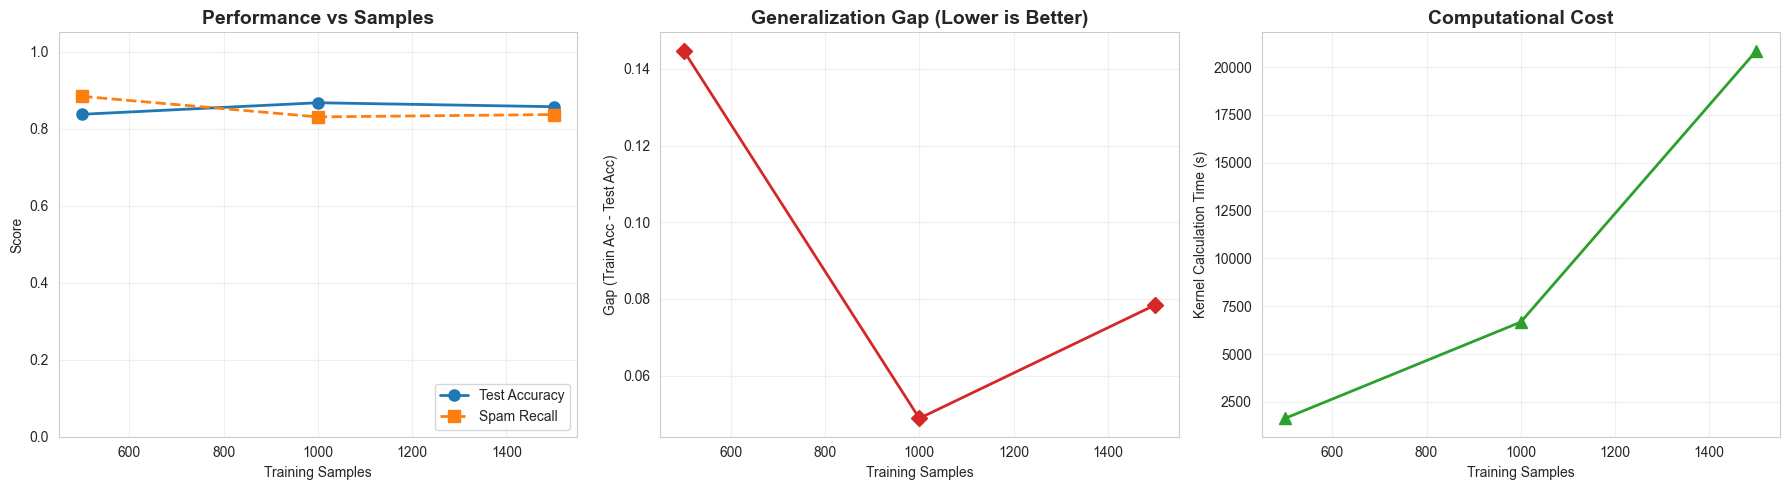


--- Plotting Exp2: Effect of Feature Dimension (Qubits) ---


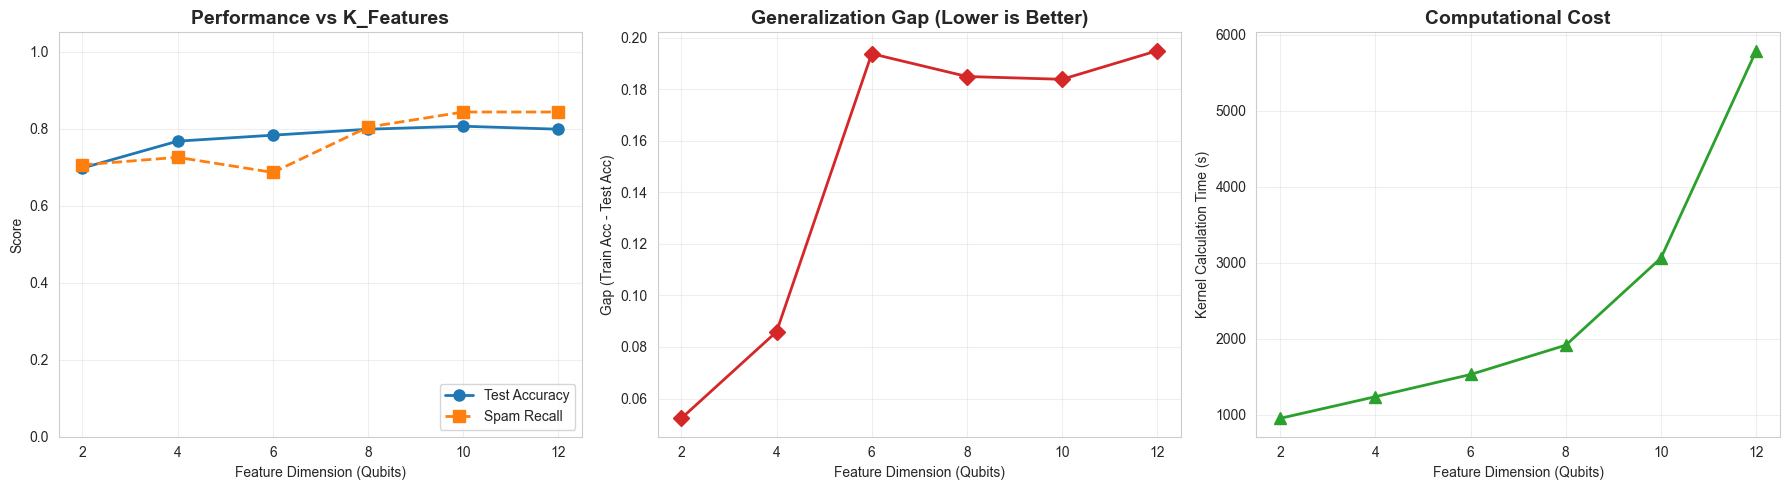


--- Plotting Exp3: Effect of Shots (Measurement) ---


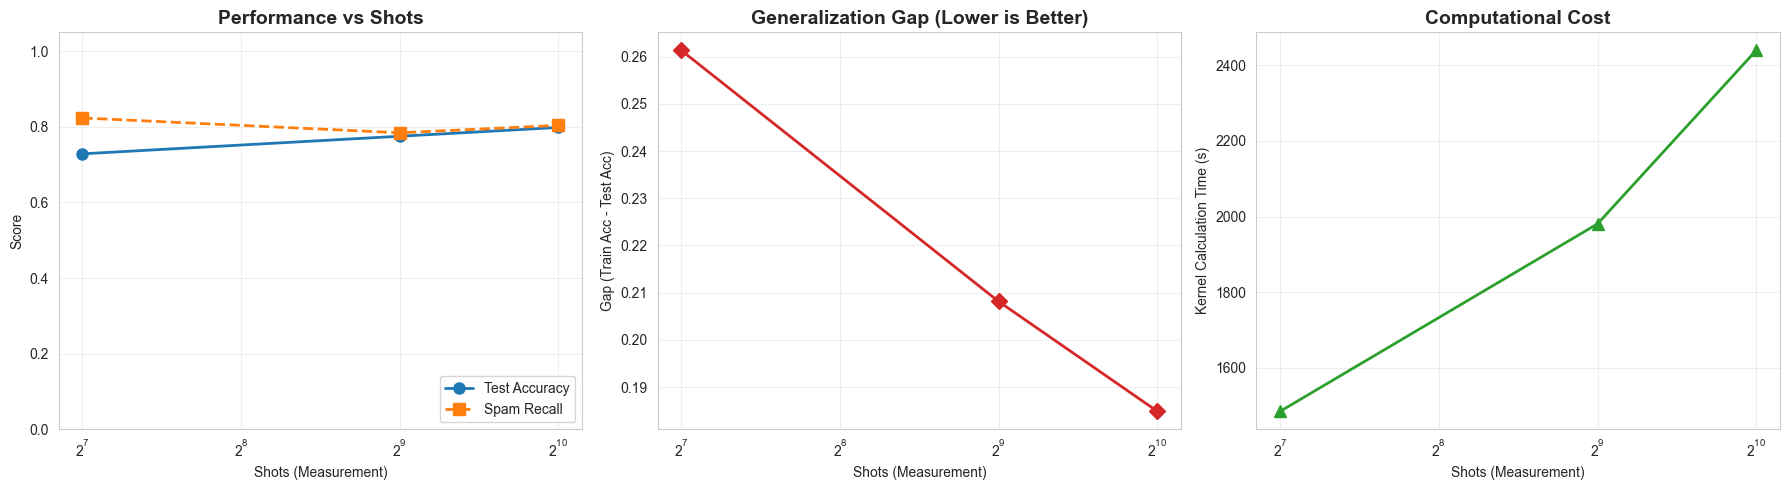


--- Plotting Exp4: Effect of Circuit Depth (Reps) ---


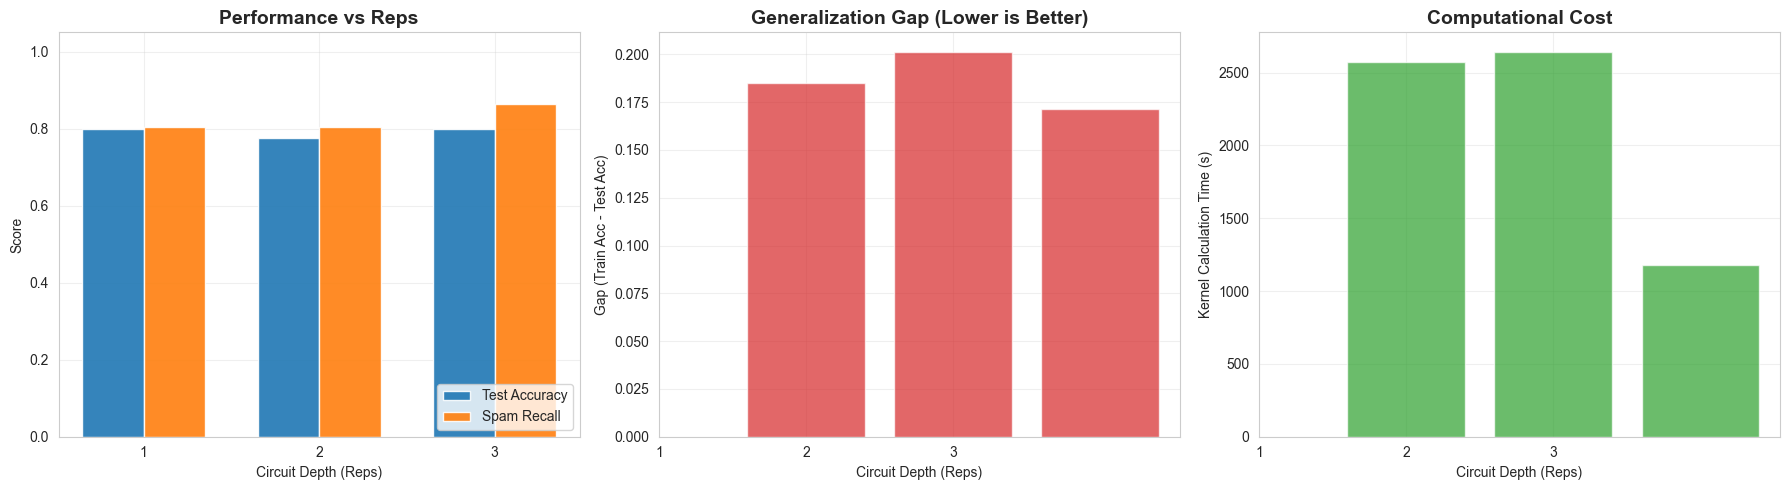


--- Plotting Exp5: Effect of Entanglement Type ---


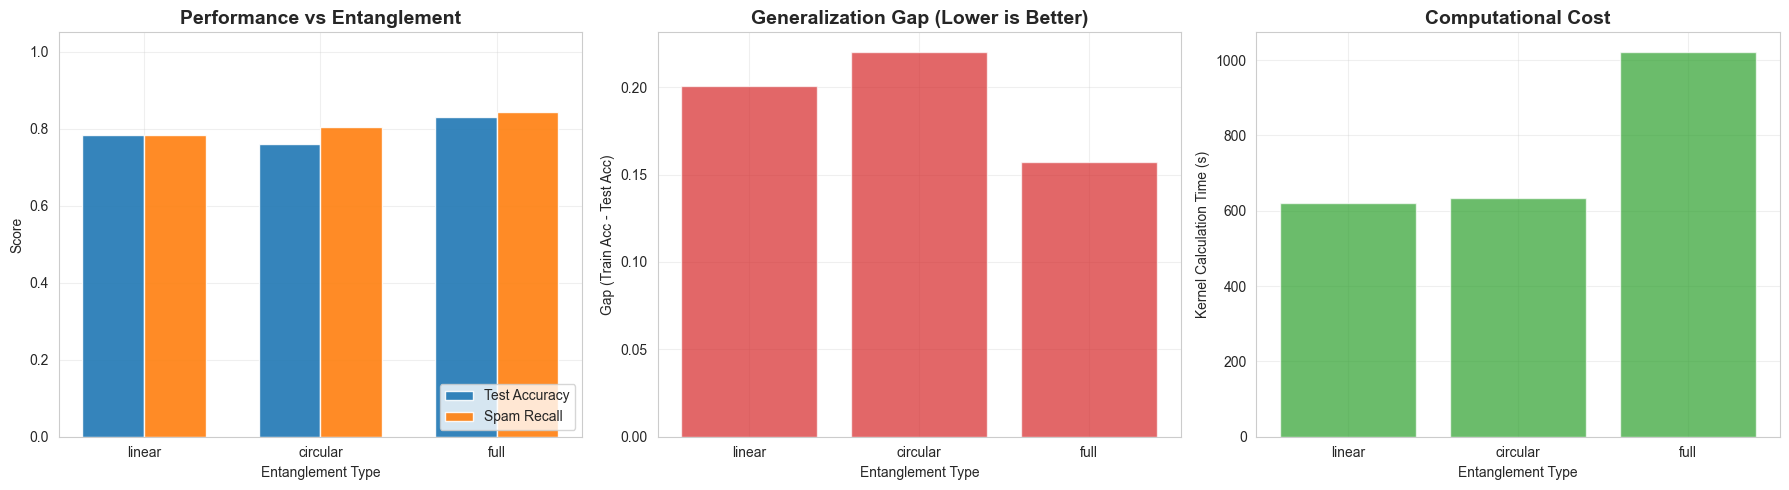


--- Global Performance Overview ---


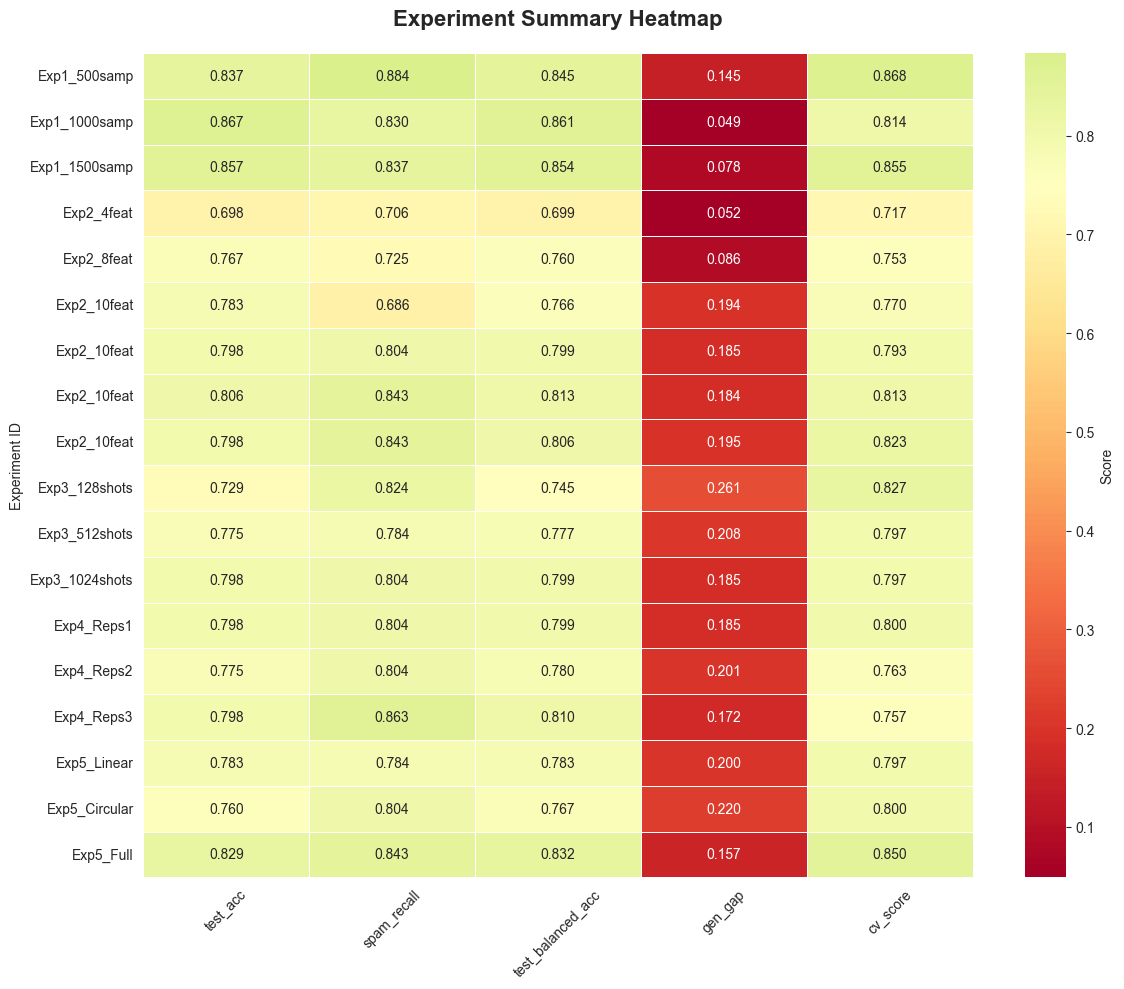

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# CONFIGURATION & STYLE
# ==========================================
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8

def plot_spambase_consistent(df):
    """
    Generates standardized visualizations for Spambase QSVM experiments.
    """
    
    # Map Experiment IDs to the parameter being varied
    exp_map = {
        'Exp1': {'param': 'samples',      'xlabel': 'Training Samples',       'log_x': False, 'type': 'line'},
        'Exp2': {'param': 'k_features',   'xlabel': 'Feature Dimension (Qubits)', 'log_x': False, 'type': 'line'},
        'Exp3': {'param': 'shots',        'xlabel': 'Shots (Measurement)',    'log_x': True,  'type': 'line'},
        'Exp4': {'param': 'reps',         'xlabel': 'Circuit Depth (Reps)',   'log_x': False, 'type': 'bar'},
        'Exp5': {'param': 'entanglement', 'xlabel': 'Entanglement Type',      'log_x': False, 'type': 'bar'}
    }

    # Iterate through each defined experiment group
    for group_key, config in exp_map.items():
        # 1. Filter data for this experiment group
        subset = df[df['experiment_id'].str.contains(group_key)].copy()
        
        if subset.empty:
            continue
            
        param = config['param']
        
        # Sort by parameter to ensure line plots are ordered correctly
        if config['type'] == 'line':
            subset = subset.sort_values(by=param)
            
        print(f"\n--- Plotting {group_key}: Effect of {config['xlabel']} ---")
        
        fig, axes = plt.subplots(1, 3)
        
        # -------------------------------------------------------
        # SUBPLOT 1: PERFORMANCE (Accuracy vs Recall)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            x_pos = np.arange(len(subset))
            width = 0.35
            # Plot bars
            axes[0].bar(x_pos - width/2, subset['test_acc'], width, label='Test Accuracy', color='#1f77b4', alpha=0.9)
            axes[0].bar(x_pos + width/2, subset['spam_recall'], width, label='Spam Recall', color='#ff7f0e', alpha=0.9)
            axes[0].set_xticks(x_pos)
            axes[0].set_xticklabels(subset[param])
        else:
            # Plot lines
            axes[0].plot(subset[param], subset['test_acc'], 'o-', label='Test Accuracy', color='#1f77b4')
            axes[0].plot(subset[param], subset['spam_recall'], 's--', label='Spam Recall', color='#ff7f0e')
            if config['log_x']: axes[0].set_xscale('log', base=2)

        axes[0].set_xlabel(config['xlabel'])
        axes[0].set_ylabel('Score')
        axes[0].set_title(f'Performance vs {config["param"].title()}')
        axes[0].set_ylim(0, 1.05)
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)

        # -------------------------------------------------------
        # SUBPLOT 2: GENERALIZATION GAP (Overfitting)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            axes[1].bar(subset[param], subset['gen_gap'], color='#d62728', alpha=0.7)
            axes[1].set_xticks(range(len(subset)))
            axes[1].set_xticklabels(subset[param])
        else:
            axes[1].plot(subset[param], subset['gen_gap'], 'D-', color='#d62728')
            if config['log_x']: axes[1].set_xscale('log', base=2)
            
        axes[1].set_xlabel(config['xlabel'])
        axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
        axes[1].set_title('Generalization Gap (Lower is Better)')
        axes[1].grid(True, alpha=0.3)

        # -------------------------------------------------------
        # SUBPLOT 3: COMPUTATIONAL COST (Time)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            axes[2].bar(subset[param], subset['kernel_time'], color='#2ca02c', alpha=0.7)
            axes[2].set_xticks(range(len(subset)))
            axes[2].set_xticklabels(subset[param])
        else:
            axes[2].plot(subset[param], subset['kernel_time'], '^-', color='#2ca02c')
            if config['log_x']: axes[2].set_xscale('log', base=2)

        axes[2].set_xlabel(config['xlabel'])
        axes[2].set_ylabel('Kernel Calculation Time (s)')
        axes[2].set_title('Computational Cost')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------
    # SUMMARY HEATMAP
    # -------------------------------------------------------
    print("\n--- Global Performance Overview ---")
    plt.figure(figsize=(12, 10))
    
    # Metrics to display in heatmap
    metrics = ['test_acc', 'spam_recall', 'test_balanced_acc', 'gen_gap', 'cv_score']
    
    # Prepare data
    heatmap_data = df.set_index('experiment_id')[metrics]
    
    # Plot
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
                center=0.75, linewidths=.5, cbar_kws={'label': 'Score'})
    
    plt.title('Experiment Summary Heatmap', fontsize=16, pad=20)
    plt.ylabel('Experiment ID')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
# Ensure results are loaded
try:
    if 'results_df' not in locals():
        results_df = pd.read_csv('qsvm_selectkbest_all_experiments.csv')
    
    # Run the visualization
    plot_spambase_consistent(results_df)
    
except Exception as e:
    print(f"Error loading data or plotting: {e}")
    print("Make sure 'results_df' is defined or the CSV file exists.")
